<a href="https://colab.research.google.com/github/khiba-k/Python_ML_Linear_Regression/blob/main/House_Size_vs_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

data = {
    'size_sqm': [30, 45, 50, None, 70, 80, 85, 90, None, 110, 120, 130, 140, 150, 160],
    'price_thousands': [80, 105, 118, 130, 155, 172, 180, 191, 200, 224, 240, 258, 270, 285, 300]
}

df = pd.DataFrame(data)

In [28]:
# Separated Independent and Dependent Variable
# Independent Variables
size_sqm_dataset = df.iloc[:, :-1].values
# Dependent Variables
price_thousands_dataset = df.iloc[:, -1].values

In [29]:
# Imputed Missing Independent Variable Values(using mean)
impute = SimpleImputer(missing_values=np.nan , strategy="mean")
size_sqm_dataset_imputed = impute.fit_transform(size_sqm_dataset)

In [30]:
# Split Training and Test Set
size_sqm_train, size_sqm_test, price_thousands_train, price_thousands_test = train_test_split(size_sqm_dataset_imputed,
                                        price_thousands_dataset, test_size=0.2, random_state=42)

In [31]:
# Sizes Scaled down
scaler = StandardScaler()
size_train_scaled = scaler.fit_transform(size_sqm_train)
size_test_scaled = scaler.transform(size_sqm_test)

In [32]:
# Fit the model
regressor = LinearRegression()
regressor.fit(size_train_scaled, price_thousands_train)

LinearRegression()

In [33]:
# Get test predictions from train size
predicted_prices_train = regressor.predict(size_train_scaled)

# Get test predictions from test size
predicted_prices_test = regressor.predict(size_test_scaled)

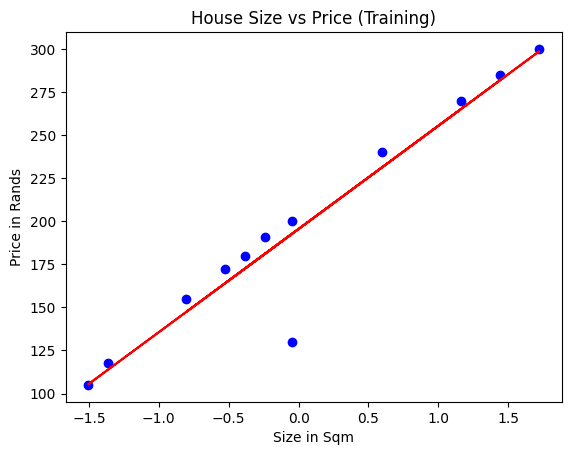

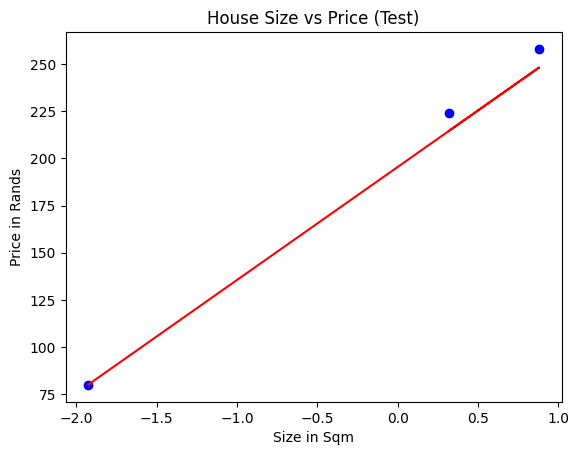

In [34]:
# Plot Actual vs Model values
# Training Set
plt.scatter(size_train_scaled, price_thousands_train, color="blue")
plt.plot(size_train_scaled, predicted_prices_train, color="red")
plt.title("House Size vs Price (Training)")
plt.xlabel("Size in Sqm")
plt.ylabel("Price in Rands")
plt.show()

print("\n")

# Test set
plt.scatter(size_test_scaled, price_thousands_test, color="blue")
plt.plot(size_test_scaled, predicted_prices_test, color="red")
plt.title("House Size vs Price (Test)")
plt.xlabel("Size in Sqm")
plt.ylabel("Price in Rands")
plt.show()